# Input Generation — Heat Pump Demand (HZ2, 4,500 kWh/year, 2026-aligned)

## Purpose

This notebook generates the **15-minute heat pump electricity demand time series** used in all archetype–DSO runs that include a heat pump (Archetypes 6, 7, 8). The profile is built using the Bayernwerk HZ2 temperature-dependent load profile (TLP) methodology, driven by Kassel 2019 weather.

**Raw input files:**  
- `raw-data/EVR_ProfilHZ2_retrieved_2026-02.xls` — HZ2 profile matrix (96 × 35, K/h)  
- `inputs/weather_kassel_t2m_2019_hourly.csv` — hourly 2m air temperature (from notebook `04_weather_kassel_merra2_2019.ipynb`)

**Output files:**  
- `inputs/hp_kassel_hz2_2026_15min.csv` — 15-min HP electricity demand (kWh, kW; 2026-aligned)  
- `inputs/hp_hz2_parameters_kassel_2026.csv` — all model parameters and optimisation-layer inputs (frozen)

## Data sources

> Bayernwerk Netz GmbH. (2020, July 2). *Temperaturabhängiges Lastprofil (TLP) für Speicherheizungen (HZ0) und Wärmepumpen (HZ2)*. https://www.bayernwerk-netz.de/
>
> Energieversorgung Rottenburg am Neckar GmbH [EVR]. (n.d.). *Profilschar HZ2* [Excel spreadsheet]. Retrieved February 2026, from https://www.evr-gmbh.de/de/Stromnetz1/Netzzugang-Entgelte/Profil-HZ2.xls
>
> Renewables.ninja. (n.d.). *Renewables.ninja* [Weather API, Kassel MERRA-2 2019]. Retrieved February 2026, from https://www.renewables.ninja/

## Methodology (Bayernwerk HZ2 TLP)

The algorithm converts daily mean outdoor temperature into a 15-minute HP electricity demand series in four steps.  
$d$ = calendar day; $T_m(d)$ = daily mean outdoor air temperature [°C] at location $d$.

1. **Equivalent temperature** — thermal inertia smoothing over a four-day window:  
   $T_{eq}(d) = 0.5\,T_m(d) + 0.3\,T_m(d{-}1) + 0.15\,T_m(d{-}2) + 0.05\,T_m(d{-}3)$

2. **Temperaturmaßzahl (TMZ)** — integer day-type index, clipped to [0, 34]:  
   $\text{TMZ}(d) = \lceil 17 - T_{eq}(d) \rceil$

3. **Annual scaling factor**:  
   $a = E_{\text{year}} \,/\, \sum_d \text{TMZ}(d)$ [kWh/K], ensures the series integrates exactly to 4,500 kWh/year.

4. **Quarter-hour energy**:  
   $E(t) = 0.25\,\text{h} \times PS(\text{slot}(t),\,\text{TMZ}(d)) \times a$  
   where $PS$ is the 96 × 35 profile matrix in K/h (sum over 96 slots = 4·TMZ by construction).

## Optimisation-layer parameters (Stute)

The HZ2 profile already gives **electricity** demand (kWhₙₗ). The COP (Coefficient of Performance) is exported here as a frozen parameter for the **solver notebooks**, which use it to:
- convert electrical HP power to thermal output: $Q_{th} = COP \times P_{el}$
- size the heat storage: $E_{HS,max} = 2\,h \times COP \times P_{HP,max,el}$

The constant COP follows Stute (2024), Eq. (18) at Kassel 2019 mean ambient (9.64 °C), $\eta_{COP}=0.4$, $T_{high}=50$ °C (Kelvin):
$COP = \eta_{COP} \cdot T_{high} / (T_{high} - T_{amb}) \approx 3.2$

## Thesis reference

Chapter 3, Section 3.5.3 — *HP Profile (HZ2)*; Appendix B, Section B.1 — *HZ2 Algorithm*

In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import xlrd
import matplotlib.pyplot as plt


# -- thesis figure rc (shared across notebooks) --
plt.rcParams.update({
    "axes.titlesize": 11,
    "axes.titleweight": "normal",
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
})

import matplotlib.dates as mdates

# ── Path configuration ─────────────────────────────────────────────────────────
def find_repo_root(marker='README.md'):
    p = Path(os.getcwd()).resolve()
    for candidate in [p, *p.parents]:
        if (candidate / marker).exists():
            return candidate
    raise RuntimeError(f'Repo root not found (looked for: {marker})')

REPO_ROOT = find_repo_root()

# Raw source files live in `raw-data/`
RAW_DATA = REPO_ROOT / 'raw-data'
if not RAW_DATA.exists():
    RAW_DATA = REPO_ROOT / 'data' / 'raw'

INPUTS = REPO_ROOT / 'inputs'
INPUTS.mkdir(parents=True, exist_ok=True)

HZ2_FILE      = RAW_DATA / 'EVR_ProfilHZ2_retrieved_2026-02.xls'
WEATHER_CSV   = INPUTS   / 'weather_kassel_t2m_2019_hourly.csv'
OUTPUT_HP     = INPUTS   / 'hp_kassel_hz2_2026_15min.csv'
OUTPUT_PARAMS = INPUTS   / 'hp_hz2_parameters_kassel_2026.csv'

# ── Fixed model parameters ─────────────────────────────────────────────────────
ANNUAL_HP_KWH   = 4500.0   # target annual HP electricity consumption [kWh/year]
T_REF           = 17.0     # Bayernwerk balance temperature [°C]
YEAR_WEATHER    = 2019
YEAR_EXPORT     = 2026     # datetime index for all pipeline outputs

# Optimisation-layer parameters (Stute 2024)
ETA_COP             = 0.4      # COP quality grade (air-to-water HP)
T_HIGH_C            = 50.0     # Stute T_high,max [°C]
T_AMB_MEAN_C        = 9.64     # Kassel 2019 annual mean ambient [°C]
T_AMB_MAX_C         = 36.86    # Kassel 2019 max ambient [°C]
Q_LOSSES_HS_PER_H   = 0.002    # HS standby losses [1/h] = 0.2 %/h
HS_CAPACITY_HOURS   = 2.0      # E_HS,max = 2 h × Q_HP,max,th

# COP: Stute Eq. (18), temperatures in Kelvin
COP_CONSTANT = round(ETA_COP * (T_HIGH_C + 273.15) / ((T_HIGH_C + 273.15) - (T_AMB_MEAN_C + 273.15)), 2)

assert HZ2_FILE.exists(),    f'HZ2 raw file not found: {HZ2_FILE}'
assert WEATHER_CSV.exists(), f'Weather CSV not found — run notebook 04 first: {WEATHER_CSV}'

print(f'HZ2 matrix    : {HZ2_FILE.name}')
print(f'Weather input : {WEATHER_CSV.name}')
print(f'HP output     : {OUTPUT_HP.name}')
print(f'Params output : {OUTPUT_PARAMS.name}')
print(f'COP (constant): {COP_CONSTANT}  (T_high={T_HIGH_C}°C, T_amb_mean={T_AMB_MEAN_C}°C, η={ETA_COP})')

HZ2 matrix    : EVR_ProfilHZ2_retrieved_2026-02.xls
Weather input : weather_kassel_t2m_2019_hourly.csv
HP output     : hp_kassel_hz2_2026_15min.csv
Params output : hp_hz2_parameters_kassel_2026.csv
COP (constant): 3.2  (T_high=50.0°C, T_amb_mean=9.64°C, η=0.4)


## Step 1 — Load weather and compute daily mean temperature

In [2]:
# Read the cleaned weather CSV produced by notebook 04.
# The series uses local_time (CET/CEST) as index — consistent with the HZ2 pipeline.
df_w = pd.read_csv(WEATHER_CSV)
df_w['local_time'] = pd.to_datetime(df_w['local_time'])
df_w = df_w.set_index('local_time').sort_index()

t2m_hourly = df_w['t2m_celsius']

# Daily mean temperature (2019)
t2m_1h     = t2m_hourly.groupby(level=0).first()  
temp_daily = t2m_1h.resample('D').mean()
temp_daily = temp_daily.loc[temp_daily.index.year == YEAR_WEATHER].copy()
temp_daily.index = temp_daily.index.normalize()

print(f'Hourly t2m : {len(t2m_hourly)} h  |  mean {t2m_hourly.mean():.2f} °C  |  range {t2m_hourly.min():.1f}–{t2m_hourly.max():.1f} °C')
print(f'Daily mean : {len(temp_daily)} days  |  range {temp_daily.min():.1f}–{temp_daily.max():.1f} °C')

Hourly t2m : 8760 h  |  mean 9.64 °C  |  range -9.0–36.9 °C
Daily mean : 365 days  |  range -6.4–28.8 °C


## Step 2 — Load HZ2 profile matrix

In [3]:
# The EVR HZ2 spreadsheet stores the 96 × 35 Profilschar matrix starting at row 7 (0-indexed),
# column 2 (0-indexed). Values are in K/h; each column corresponds to one TMZ (0..34),
# each row to one quarter-hour of the day (slot 0 = 00:00–00:15, slot 95 = 23:45–24:00).
# Bayernwerk normalisation: sum of all 96 slots in column TMZ equals 4 × TMZ.
wb  = xlrd.open_workbook(str(HZ2_FILE))
ws  = wb.sheet_by_index(0)
ps  = np.zeros((96, 35))
for slot in range(96):
    for tmz in range(35):
        ps[slot, tmz] = ws.cell_value(slot + 7, tmz + 2)

# Peek at upper-left corner (first slots × first TMZ columns), K/h
_head_r, _head_c = 6, 8
with np.printoptions(precision=4, suppress=True, linewidth=120):
    print(f"PS head ({_head_r} × {_head_c}):\n{ps[:_head_r, :_head_c]}")

# Bayernwerk rule: column k (= TMZ value) must sum to 4*k over 96 quarter-hour slots.
# (PS units are K/h; 4 slots/h * k * 1 h = 4k.)
col_sums     = ps.sum(axis=0)
expected     = np.array([4.0 * k for k in range(35)])
max_abs_err  = float(np.max(np.abs(col_sums - expected)))
rel_err      = np.abs((col_sums[1:] - expected[1:]) / expected[1:])
max_rel_err  = float(np.max(rel_err))

print(f'HZ2 matrix shape : {ps.shape}  (expected 96 × 35)')
print(f'Min value        : {ps.min():.4f}  (expected ≥ 0)')
print(f'Normalisation    : max abs error = {max_abs_err:.2e}  |  max rel error (TMZ≥1) = {max_rel_err:.2e}')
assert ps.shape == (96, 35)
assert ps.min() >= -1e-12
assert max_abs_err < 1e-10, 'HZ2 normalisation check failed'

PS head (6 × 8):
[[0.     0.1535 0.2846 0.394  0.4726 0.5474 0.5867 0.6801]
 [0.     0.1644 0.3098 0.4288 0.4769 0.5527 0.635  0.71  ]
 [0.     0.1402 0.287  0.4286 0.4709 0.5444 0.615  0.6999]
 [0.     0.1412 0.2643 0.38   0.4746 0.5488 0.6211 0.7034]
 [0.     0.1418 0.2658 0.3728 0.4763 0.5493 0.6216 0.7595]
 [0.     0.1941 0.2684 0.3774 0.4801 0.5538 0.628  0.711 ]]
HZ2 matrix shape : (96, 35)  (expected 96 × 35)
Min value        : 0.0000  (expected ≥ 0)
Normalisation    : max abs error = 5.68e-14  |  max rel error (TMZ≥1) = 4.44e-16


## Step 3 — Compute TMZ series and build 15-min HP demand

In [4]:
def calc_tmz_series(temp_daily, t_ref=17.0):
    """Compute the daily TMZ index following Bayernwerk Eq. (1)–(2).
    """
    tmz = {}
    dates = temp_daily.index
    for i, d in enumerate(dates):
        tm0 = temp_daily.iloc[i]
        tm1 = temp_daily.iloc[max(0, i - 1)]
        tm2 = temp_daily.iloc[max(0, i - 2)]
        tm3 = temp_daily.iloc[max(0, i - 3)]
        t_eq   = 0.5 * tm0 + 0.3 * tm1 + 0.15 * tm2 + 0.05 * tm3
        tmz[d] = int(np.clip(np.ceil(t_ref - t_eq), 0, 34))
    return pd.Series(tmz)


def build_hp_15min(ps, tmz_series, annual_kwh, year=2019):
    """Build the 15-min HP electricity demand series (kWh/slot).
    Scaling factor a = annual_kwh / sum(TMZ) ensures exact annual total.
    """
    sum_tmz = float(tmz_series.sum())
    a       = annual_kwh / sum_tmz
    idx     = pd.date_range(f'{year}-01-01 00:00', f'{year}-12-31 23:45', freq='15min')
    vals    = np.zeros(len(idx))
    for i, ts in enumerate(idx):
        slot   = ts.hour * 4 + ts.minute // 15
        tmz_d  = tmz_series.get(ts.normalize(), 0)
        vals[i] = 0.25 * ps[slot, tmz_d] * a
    return pd.Series(vals, index=idx), a, sum_tmz


tmz_series        = calc_tmz_series(temp_daily, t_ref=T_REF)
hp_15min, a, sum_tmz = build_hp_15min(ps, tmz_series, ANNUAL_HP_KWH, year=YEAR_WEATHER)

print(f'TMZ range   : {tmz_series.min()} – {tmz_series.max()}')
print(f'Sum TMZ     : {sum_tmz:.0f} K')
print(f'Scaling a   : {a:.6f} kWh/K')
print(f'Annual total: {hp_15min.sum():.2f} kWh  (target: {ANNUAL_HP_KWH:.0f} kWh)')
print(f'Peak power  : {hp_15min.max() / 0.25:.3f} kW')

TMZ range   : 0 – 24
Sum TMZ     : 3068 K
Scaling a   : 1.466754 kWh/K
Annual total: 4500.00 kWh  (target: 4500 kWh)
Peak power  : 5.209 kW


## Step 4 — Visualise HP demand profile

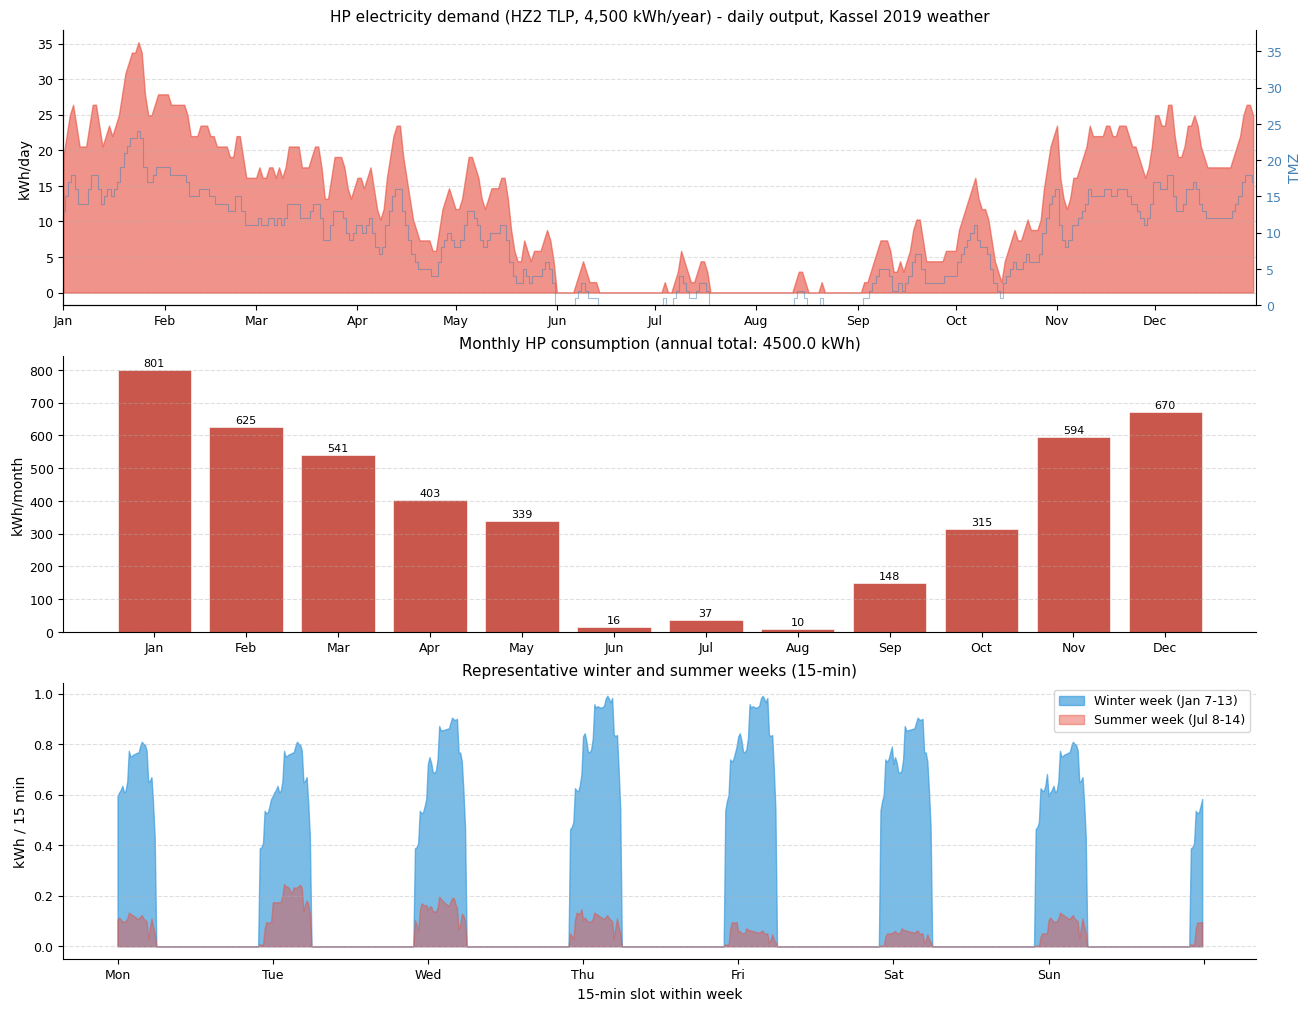

In [5]:
monthly_kwh = hp_15min.resample('MS').sum()
hp_hourly   = hp_15min.resample('h').sum()

fig, axes = plt.subplots(3, 1, figsize=(13, 10), constrained_layout=True)

daily_kwh = hp_15min.resample('D').sum()
ax0 = axes[0]
ax0.fill_between(daily_kwh.index, daily_kwh.values, 0, color='#e74c3c', alpha=0.6)
ax0.set_ylabel('kWh/day')
ax0.set_title(
    'HP electricity demand (HZ2 TLP, 4,500 kWh/year) - daily output, Kassel 2019 weather'
)
ax0.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax0.xaxis.set_major_locator(mdates.MonthLocator())
ax0.set_xlim(hp_15min.index[0], hp_15min.index[-1])
ax0.grid(axis='y', linestyle='--', alpha=0.4)
ax0.spines[['top', 'right']].set_visible(False)

ax0b = ax0.twinx()
ax0b.step(tmz_series.index, tmz_series.values, where='mid',
          color='steelblue', alpha=0.5, lw=0.8, label='TMZ')
ax0b.set_ylabel('TMZ', color='steelblue')
ax0b.tick_params(axis='y', labelcolor='steelblue', labelsize=9)
ax0b.set_ylim(0, 38)
ax0b.spines['top'].set_visible(False)

ax1 = axes[1]
month_labels = monthly_kwh.index.strftime('%b')
bars = ax1.bar(range(12), monthly_kwh.values, color='#c0392b', alpha=0.85,
               edgecolor='white', linewidth=0.5)
ax1.set_xticks(range(12))
ax1.set_xticklabels(month_labels)
ax1.set_ylabel('kWh/month')
ax1.set_title(f'Monthly HP consumption (annual total: {monthly_kwh.sum():.1f} kWh)')
ax1.grid(axis='y', linestyle='--', alpha=0.4)
ax1.spines[['top', 'right']].set_visible(False)
for bar, val in zip(bars, monthly_kwh.values):
    if val > 0:
        ax1.text(bar.get_x() + bar.get_width() / 2, val + 5,
                 f'{val:.0f}', ha='center', va='bottom', fontsize=8)

ax2 = axes[2]
win  = hp_15min.loc['2019-01-07':'2019-01-13 23:45']
summ = hp_15min.loc['2019-07-08':'2019-07-14 23:45']
ax2.fill_between(range(len(win)),  win.values,  0, color='#3498db', alpha=0.65, label='Winter week (Jan 7-13)')
ax2.fill_between(range(len(summ)), summ.values, 0, color='#e74c3c', alpha=0.45, label='Summer week (Jul 8-14)')
ax2.set_xlabel('15-min slot within week')
ax2.set_ylabel('kWh / 15 min')
ax2.set_title('Representative winter and summer weeks (15-min)')
xt = [i * 96 for i in range(8)]
xl = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun', '']
ax2.set_xticks(xt)
ax2.set_xticklabels(xl)
ax2.legend()
ax2.grid(axis='y', linestyle='--', alpha=0.4)
ax2.spines[['top', 'right']].set_visible(False)

plt.show()


## Step 5 — Summary statistics

In [6]:
peak_kw = float((hp_15min / 0.25).max())

print('HP Demand (HZ2, 4,500 kWh/year) — Summary')
print('-' * 50)
print(f'  Annual total         : {hp_15min.sum():.2f} kWh')
print(f'  Peak power           : {peak_kw:.3f} kW')
print(f'  Scaling factor a     : {a:.6f} kWh/K')
print(f'  Sum TMZ              : {sum_tmz:.0f} K')
print(f'  TMZ range            : {tmz_series.min()} – {tmz_series.max()}')
print(f'  Days with HP demand  : {(tmz_series > 0).sum()} of {len(tmz_series)}')
print()
print('Optimisation-layer parameters (Stute 2024)')
print('-' * 50)
print(f'  COP (constant)       : {COP_CONSTANT}')
print(f'  η_COP                : {ETA_COP}')
print(f'  T_high               : {T_HIGH_C} °C')
print(f'  T_amb mean           : {T_AMB_MEAN_C} °C  (Kassel 2019)')
print(f'  HS standby losses    : {Q_LOSSES_HS_PER_H} /h  ({Q_LOSSES_HS_PER_H*100:.1f} %/h)')
print(f'  HS capacity          : {HS_CAPACITY_HOURS} h × Q_HP,max,th')
print('-' * 50)

HP Demand (HZ2, 4,500 kWh/year) — Summary
--------------------------------------------------
  Annual total         : 4500.00 kWh
  Peak power           : 5.209 kW
  Scaling factor a     : 1.466754 kWh/K
  Sum TMZ              : 3068 K
  TMZ range            : 0 – 24
  Days with HP demand  : 295 of 365

Optimisation-layer parameters (Stute 2024)
--------------------------------------------------
  COP (constant)       : 3.2
  η_COP                : 0.4
  T_high               : 50.0 °C
  T_amb mean           : 9.64 °C  (Kassel 2019)
  HS standby losses    : 0.002 /h  (0.2 %/h)
  HS capacity          : 2.0 h × Q_HP,max,th
--------------------------------------------------


## Step 6 — Export to CSV

In [7]:
# ── 6a. HP 15-min time series (datetime aligned to 2026) ───────────────────────
# The weather data is a 2019 proxy year; datetimes are shifted to 2026 so that
# the HP series shares the same temporal index as all other pipeline inputs.
idx_2026 = pd.date_range('2026-01-01 00:00', periods=len(hp_15min), freq='15min')

df_hp = pd.DataFrame({
    'datetime'   : idx_2026.strftime('%Y-%m-%d %H:%M'),
    'energy_kWh' : hp_15min.values.round(8),
    'power_kW'   : (hp_15min.values / 0.25).round(8),
})
df_hp.to_csv(OUTPUT_HP, index=False)

# Frozen Q_HP,max,el for HS sizing (peak × 1.2; stored once to prevent drift if profile changes)
Q_HP_MAX_EL_KW = float(df_hp['power_kW'].max()) * 1.2

print(f'Exported HP series : {OUTPUT_HP.name}  ({len(df_hp):,} rows)')
print(df_hp.head(4).to_string(index=False))

# ── 6b. Frozen parameter table ─────────────────────────────────────────────────
rows = [
    # Profile provenance
    ('location',                  'Kassel',            'same as PV/weather'),
    ('year_weather',              YEAR_WEATHER,        'proxy weather year (Kassel MERRA-2)'),
    ('year_export',               YEAR_EXPORT,         'CSV datetime aligned to this year'),
    ('annual_hp_kwh_target',      ANNUAL_HP_KWH,       'kWh/year'),
    ('T_ref_C',                   T_REF,               'Bayernwerk balance temperature'),
    ('profile_matrix_file',       HZ2_FILE.name,       'Energieversorgung Rottenburg; valid from 2011-08-01'),
    ('weather_input_file',        WEATHER_CSV.name,    'from notebook 04_weather_kassel_merra2_2019'),
    # Derived
    ('tmz_min',                   int(tmz_series.min()),  ''),
    ('tmz_max',                   int(tmz_series.max()),  ''),
    ('tmz_sum',                   float(sum_tmz),         'K'),
    ('scaling_a_kWh_per_K',       float(a),               'a = annual_kWh / sum(TMZ)'),
    # Formulas
    ('formula_equivalent_temp',   'T_eq(d)=0.5*T_m(d)+0.3*T_m(d-1)+0.15*T_m(d-2)+0.05*T_m(d-3)', 'Bayernwerk Eq.(1)'),
    ('formula_tmz',               'TMZ(d)=ceil(T_ref-T_eq(d)); clip(0,34)',                         'Bayernwerk Eq.(2)'),
    ('formula_scaling',           'a = annual_kWh / sum_d TMZ(d)',                                  'Bayernwerk Eq.(3)'),
    ('formula_15min_energy',      'E(t)[kWh] = 0.25h * PS(slot(t),TMZ(d)) [K/h] * a [kWh/K]',     'Bayernwerk Eq.(4)'),
    ('PS_units',                  'K/h',                  'sum over 96 slots = 4*TMZ'),
    # Optimisation layer (Stute 2024)
    ('opt_eta_COP',               ETA_COP,                'COP quality grade, Stute air-to-water'),
    ('opt_T_high_C',              T_HIGH_C,               'Stute T_high,max [°C]'),
    ('opt_T_amb_mean_C',          T_AMB_MEAN_C,           'Kassel 2019 annual mean [°C]'),
    ('opt_T_amb_max_C',           T_AMB_MAX_C,            'Kassel 2019 max [°C]'),
    ('opt_COP_constant',          COP_CONSTANT,           'Stute Eq.(18) at Kassel 2019 mean T_amb, Kelvin'),
    ('opt_q_losses_HS_per_h',     Q_LOSSES_HS_PER_H,      'HS standby 0.2 %/h (Stute)'),
    ('opt_HS_capacity_hours',     HS_CAPACITY_HOURS,      'E_HS,max = 2h * Q_HP,max,th (Stute)'),
    ('opt_Q_HP_max_el_kW',        Q_HP_MAX_EL_KW,         'peak(power_kW) × 1.2; frozen at export time'),
    # Integrity
    ('check_shape_ok',            str(ps.shape == (96, 35)),  'expected (96, 35)'),
    ('check_min_value',           float(ps.min()),            'should be >= 0'),
    ('check_norm_max_abs_err',    max_abs_err,                'max(|sum_slots - 4*TMZ|)'),
    ('check_norm_max_rel_err',    max_rel_err,                'max rel error for TMZ>=1'),
]

df_params = pd.DataFrame(rows, columns=['parameter', 'value', 'notes'])
df_params.to_csv(OUTPUT_PARAMS, index=False)
print(f'\nExported parameters: {OUTPUT_PARAMS.name}  ({len(df_params)} rows)')

Exported HP series : hp_kassel_hz2_2026_15min.csv  (35,040 rows)
        datetime  energy_kWh  power_kW
2026-01-01 00:00    0.533628  2.134512
2026-01-01 00:15    0.539997  2.159989
2026-01-01 00:30    0.553382  2.213528
2026-01-01 00:45    0.571601  2.286403

Exported parameters: hp_hz2_parameters_kassel_2026.csv  (28 rows)
